In [1]:
%%capture
# Перед началом работы с библиотеками pandas и seaborn необходимо установить их в Python.
# Сделать это можно, исполнив данную ячейку
!pip3 install pandas
!pip3 install seaborn

In [2]:
import math

import pandas as pd
import seaborn as sns

In [3]:
# Настройка, которая позволяет сделать графики, которые рисует seaborn, более крупными
sns.set(rc={'figure.figsize': (11.7, 8.27)})

In [4]:
def round_to_2(x):
    """
    Принимает число и возвращает результат его округления
    до 2 знаков после запятой.
    
    Аргументы:
        x: Число.
        
    Возвращаемое значение:
        Результат округления числа до 2 знаков после запятой.
    """
    
    return round(x, 2)

## Среднее значение в колонке csv-файла

In [5]:
def split_line(line, sep):
    """
    Возвращает список значений, которые содержатся в строке
    и разделены конкретным разделителем.
    Если какое-то из значений обособлено кавычками ("<значение>"), то разделительный
    символ внутри него не считается разделителем.
    
    Например, если передать в функцию строку 'aa,bb,"cc, oo",dd' и разделитель ',',
    то в результате работы функции получится список ['aa', 'bb', 'cc, oo', 'dd'].
    
    Аргументы:
        line: Строка, которую нужно разбить на подстроки.
        sep: Разделитель, который используется в строке для отделения различных значений.
        
    Возвращаемое значение:
        Список подстрок строки, получаемых с помощью разделения её
        на подстроки по заданному разделителю.
    """
    
    res = []
    
    prev_ind = -1
    in_quotes = False
    
    for i in range(len(line)):
        ch = line[i]
        
        if ch == '"':
            in_quotes = not in_quotes
            
        if not in_quotes and ch == sep:
            res.append(line[prev_ind + 1:i].strip('"'))
            prev_ind = i
            
    if prev_ind < len(line) - 1:
        res.append(line[prev_ind + 1:len(line)].strip('"'))
    elif prev_ind == len(line) - 1:
        res.append('')
    
    return res

In [6]:
def read_csv_and_calc_mean_solution(lines, sep, column_name):
    """
    Принимает список строк из csv-файла и возвращает среднее значение в заданной колонке.
    В первой строке csv-файла всегда представлены названия его колонок.
    
    Аргументы:
        lines: Список строк, прочитанных из csv-файла.
        sep: Разделитель, который используется в строках для отделения различных значений.
        column_name: Название колонки с целочисленными значениями, по которой нужно посчитать среднее.
        
    Возвращаемое значение:
        Среднее значение в заданной колонке, округлённое до 2 знаков
        после запятой с помощью функции round_to_2.
    """
    first_line = split_line(lines[0], sep)
    index = first_line.index(column_name)

    summ = 0
    n = len(lines) - 1
    for i in range(1, len(lines)):
        line = split_line(lines[i], sep)
        summ += int(line[index])

    return round_to_2(summ / n)

In [7]:
def read_csv_and_calc_mean_tests():
    example_1_lines = [
        'Жанр,"Продолжительность, часы","Продолжительность, минуты",Страна производства,Год производства',
        'Боевик,0,36,Италия,1996',
        'Комедия,1,23,Россия,1999',
        'Триллер,2,21,США,2006',
    ]
    example_1_sep = ','
    example_1_column = 'Год производства'
    example_1_res = 2000.33
    
    assert read_csv_and_calc_mean_solution(example_1_lines, example_1_sep, example_1_column) == example_1_res
    
    example_2_lines = [
        'Жанр,"Продолжительность, часы","Продолжительность, минуты",Страна производства,Год производства',
        'Боевик,0,36,Италия,1996',
        'Комедия,1,23,Россия,1999',
        'Триллер,2,21,США,2006',
        'Комедия,1,48,США-Россия,2012',
        'Драма,2,3,Франция,2016',
        'Документальный,2,47,Германия,2001'
    ]
    example_2_sep = ','
    example_2_column = 'Продолжительность, минуты'
    example_2_res = 29.67
    
    assert read_csv_and_calc_mean_solution(example_2_lines, example_2_sep, example_2_column) == example_2_res
    
    print('Все тесты прошли успешно!')

In [8]:
read_csv_and_calc_mean_tests()

Все тесты прошли успешно!


## Фильтрация таблиц

In [9]:
# В переменную movies загружена таблица из файла movies_data.csv
movies = pd.read_csv(r'C:\Users\staso\Jupyter Projects\Sirius\3\movies_data.csv', sep=',')

# Удаление фильмов, у которых не указан год производства
movies = movies[~movies['Год производства'].isna()]

In [10]:
print(movies.head())
print(movies.shape)

      Жанр фильма Продолжительность, часы  Продолжительность, минуты  \
0           Драма                      35                         42   
1           Драма                       1                         16   
2  Документальный                       1                         45   
3           Драма              нет данных                         42   
4         Комедия                       1                         43   

  Страна производства  Год производства  
0              Италия            2008.0  
1              Италия            2007.0  
2                 США            2005.0  
3            Германия            2009.0  
4             Франция            2009.0  
(9008, 5)


In [11]:
print(len(movies[(movies['Страна производства'] == 'Франция') & (movies['Жанр фильма'] == 'Драма')]))

235


In [12]:
print(len(movies[(movies['Страна производства'] == 'Россия') & (movies['Год производства'] > 2010)]))

1312


In [13]:
print(len(movies[(movies['Страна производства'] == 'Россия') | ((movies['Год производства'] < 2000) & (movies['Жанр фильма'] == 'Триллер'))]))

3299


## Комбинирование колонок и расчёт статистик

In [14]:
# В переменную movies_budget загружена таблица из файла movies_budget.csv
movies_budget = pd.read_csv(r'C:\Users\staso\Jupyter Projects\Sirius\3\movies_budget.csv', sep=';')

In [20]:
print(movies_budget.head())

  Жанр фильма Страна производства   Бюджет  Число зрителей  Стоимость билета
0       Драма                 США  5932617          465141               350
1     Триллер            Германия  1007872          141702               220
2     Триллер             Франция  1277422          114760               350
3     Комедия      Россия-Франция   880262           71666               400
4      Боевик              Россия  2114068           96311               400


In [24]:
print((movies_budget['Число зрителей'] * movies_budget['Стоимость билета']).mean())

67278893.76


прибыль=12⋅доход от продажи билетов−бюджет−расходы на рекламу,

In [27]:
income = 1/2 * (movies_budget['Число зрителей'] * movies_budget['Стоимость билета']) - 3/2 * movies_budget['Бюджет']
print(income.max())

150431902.0


## Агрегированные статистики

In [62]:
# В переменную movies_budget загружена таблица из файла movies_budget.csv
movies_budget = pd.read_csv('movies_budget.csv', sep=';')

In [63]:
print(movies_budget.shape)
print(movies_budget.dtypes)
print(movies_budget.size)

(1000, 5)
Жанр фильма            object
Страна производства    object
Бюджет                  int64
Число зрителей          int64
Стоимость билета        int64
dtype: object
5000


In [65]:
print(movies_budget.head())

  Жанр фильма Страна производства   Бюджет  Число зрителей  Стоимость билета
0       Драма                 США  5932617          465141               350
1     Триллер            Германия  1007872          141702               220
2     Триллер             Франция  1277422          114760               350
3     Комедия      Россия-Франция   880262           71666               400
4      Боевик              Россия  2114068           96311               400


In [72]:
movies_budget.groupby('Жанр фильма', as_index=False) \
             .aggregate({'Число зрителей': 'sum'})  \
             .sort_values('Число зрителей', ascending=False)

,Жанр фильма,Число зрителей
2,Драма,144536483
4,Триллер,30519114
0,Боевик,20859969
1,Документальный,10093471
3,Комедия,9920914


In [73]:
movies_budget.groupby('Жанр фильма', as_index=False) \
             ['Число зрителей'].sum()  \
             .sort_values('Число зрителей', ascending=False)

,Жанр фильма,Число зрителей
2,Драма,144536483
4,Триллер,30519114
0,Боевик,20859969
1,Документальный,10093471
3,Комедия,9920914


In [80]:
def transform_countries_info(movies_data):
    """
    Принимает таблицу с колонкой «Страна производства» и добавляет к таблице 5 новых колонок:
    по одной на каждую отдельную страну. Значение в каждой из колонок соответствует тому,
    принимала ли конкретная страна участие в производстве фильма.
    
    Аргументы:
        movies_data: Исходная таблица с клонкой «Страна производства».
        
    Возвращаемое значение:
        Нет. Функция модифицирует переданную таблицу, но ничего не возвращает.
    """
    
    countries = ['Россия', 'Германия', 'США', 'Италия', 'Франция']
    new_columns = [[] for i in range(len(countries))]
    
    for _, row in movies_data.iterrows():
        country_of_origin_united = row['Страна производства']
        countries_of_origin = country_of_origin_united.split('-')
        
        for i in range(len(countries)):
            country = countries[i]
            
            if country in countries_of_origin:
                new_columns[i].append('Да')
            else:
                new_columns[i].append('Нет')
                
    for i in range(len(countries)):
        movies_data[countries[i]] = new_columns[i]

    return movies_data

In [107]:
russian_movies = movies_budget[transform_countries_info(movies_budget)['Россия'] == 'Да']
print(russian_movies.head())

   Жанр фильма Страна производства   Бюджет  Число зрителей  Стоимость билета  \
3      Комедия      Россия-Франция   880262           71666               400   
4       Боевик              Россия  2114068           96311               400   
8       Боевик              Россия  2706451          124616               350   
14     Триллер              Россия  2714571           52028               150   
19       Драма              Россия  2664837          495846               400   

   Россия Германия  США Италия Франция  
3      Да      Нет  Нет    Нет      Да  
4      Да      Нет  Нет    Нет     Нет  
8      Да      Нет  Нет    Нет     Нет  
14     Да      Нет  Нет    Нет     Нет  
19     Да      Нет  Нет    Нет     Нет  


## Визуальный анализ данных

In [119]:
print( \
    russian_movies.groupby('Жанр фильма', as_index=False) \
              .size() \
              .rename(columns={'size': 'Число фильмов'}) \
              .sort_values('Число фильмов', ascending=False) \
)

      Жанр фильма  Число фильмов
2           Драма            123
4         Триллер            111
0          Боевик             77
1  Документальный             40
3         Комедия             33


In [109]:
# В переменную many_factors загружена таблица из файла many_factors_data.csv
many_factors = pd.read_csv('many_factors_data.csv')

In [123]:
print(many_factors.head(), many_factors.shape, many_factors.dtypes, sep='\n\n')

          A         B         C         D         E
0  0.464512  0.215771  0.211649  0.213262  0.460054
1 -0.968919  0.938804  0.349538  0.357078  0.591217
2  0.556104  0.309251  0.015493  0.015493  0.124470
3 -0.437593  0.191487 -0.186278 -0.187373  0.431600
4 -0.525049  0.275676  0.091514  0.091642  0.302513

(1000, 5)

A    float64
B    float64
C    float64
D    float64
E    float64
dtype: object


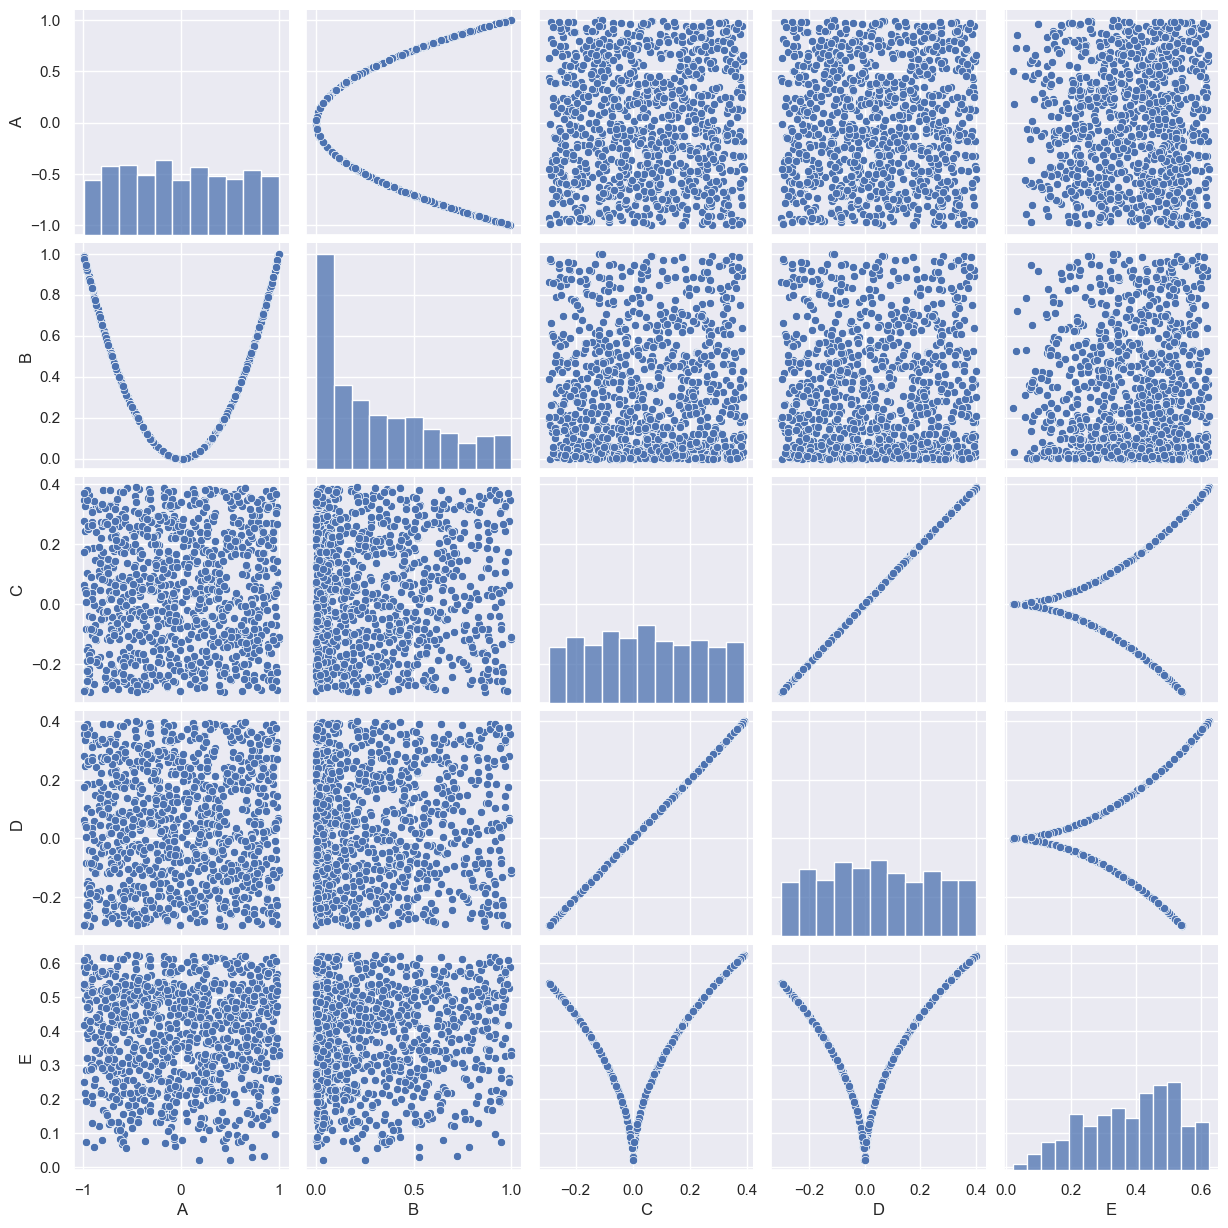

In [144]:
#sns.pairplot(many_factors[['A', 'B', 'C', 'D', 'E']])
sns.pairplot(many_factors[[x for x in many_factors.columns.values]])

In [142]:
print(many_factors.columns.values)

['A' 'B' 'C' 'D' 'E']


In [145]:
# В переменную uniform_and_not загружена таблица из файла uniform_and_not_data
uniform_and_not = pd.read_csv('uniform_and_not_data.csv')

In [147]:
print(uniform_and_not.head())

          A         B         C         D         E
0 -0.216533  3.313403  3.664743 -0.047255  0.386616
1 -0.003454  3.854757 -5.088873 -0.725561  0.000033
2 -0.585603  7.018951 -1.380724  0.691111  0.355108
3  0.175861  1.493150  6.155430 -0.379548  0.650187
4  0.816606  6.293888  0.957381 -0.816596  0.066945


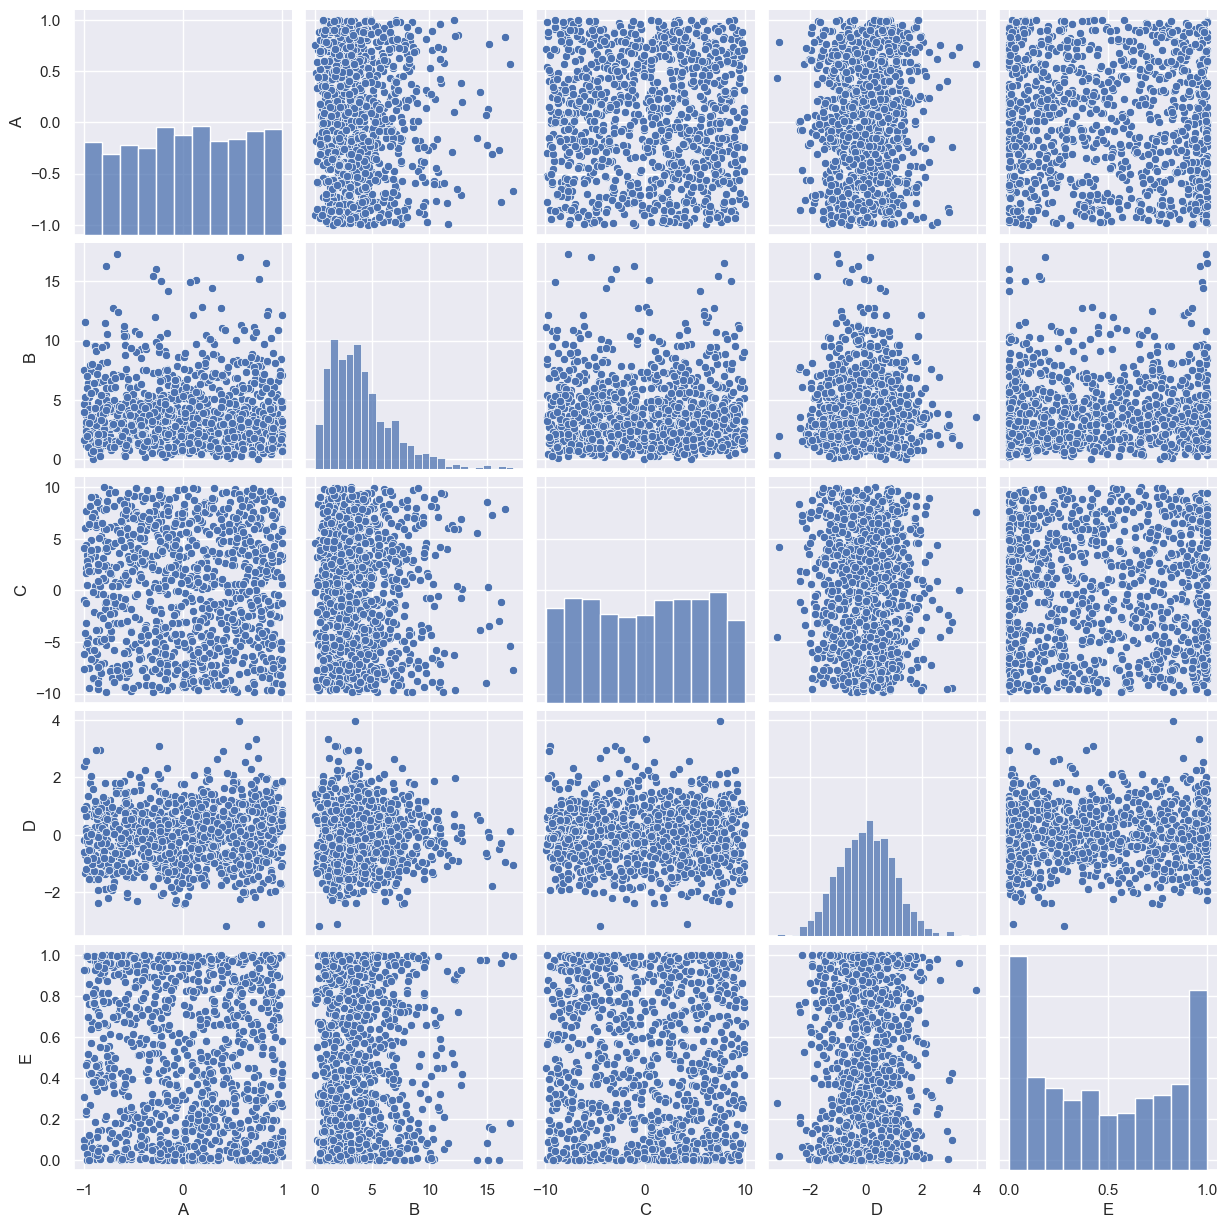

In [151]:
sns.pairplot(uniform_and_not[[x for x in uniform_and_not.columns.values]])

In [173]:
studio = pd.read_csv('untitled.csv')

In [174]:
print(studio)
print(studio.shape)

  Студия  \tЧисло зрителей
0    ABC          25000000
1    ABC          29000000
2    CDE          14000000
3    FGH           7000000
4    CDE          22000000
5    FGH          31000000
6    CDE          18000000
(7, 2)


In [175]:
studio.rename(columns={'\tЧисло зрителей' : 'Число зрителей'}, inplace=True)

In [176]:
print(studio)

  Студия  Число зрителей
0    ABC        25000000
1    ABC        29000000
2    CDE        14000000
3    FGH         7000000
4    CDE        22000000
5    FGH        31000000
6    CDE        18000000


In [183]:
studio.groupby('Студия')['Число зрителей'].mean()

Студия
ABC    27000000.0
CDE    18000000.0
FGH    19000000.0
Name: Число зрителей, dtype: float64

In [188]:
a = {set([1, 2]): [1, 2, 3]}

TypeError: unhashable type: 'set'

In [196]:
a = set([1,2])

In [197]:
a.add(3)
print(a)
a.

{1, 2, 3}
